# Praktikum 07 | ML Senin Pagi

Nama : Rika Rahma

NIM : 011022214

Rombel : TI08 - 2022

1. Import Library

In [1]:
# Import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
# Import library Statsmodels untuk OLS
import statsmodels.api as sm

In [2]:
# Menghubungkan colab dengan Google Drive
from google.colab import drive
drive.mount ('/content/gdrive')

Mounted at /content/gdrive


In [3]:
# Memanggil dataset lewat Gdrive
path = '/content/gdrive/MyDrive/Praktikum_ML/praktikum07/data/'

In [4]:
# Membaca file CSV menggunakan pandas
df = pd.read_csv(path + 'dataset_satelit.csv')
df.head()

,No,Longitude,Lattitude,N,P,K,Ca,Mg,Fe,Mn,...,b1,Sigma_VV,Sigma_VH,plia,lia,iafe,gamma0_vv,gamma0_vh,beta0_vv,beta0_vh
0,1,103.036658,-0.604417,2.64,0.15,0.415,0.51,0.31,119.96,463.23,...,0.0433,0.18183,0.04461,35.74446,35.79744,35.41161,0.22331,0.05479,0.31325,0.07686
1,2,103.037201,-0.604689,2.75,0.17,0.568,0.76,0.58,102.63,493.81,...,0.0465,0.22079,0.04640,35.12096,35.14591,35.41510,0.27116,0.05699,0.38033,0.07993
2,3,103.036359,-0.603012,1.77,0.12,0.339,0.49,0.6,107.37,460.93,...,0.0417,0.18926,0.03992,35.07724,35.07730,35.41135,0.23242,0.04902,0.32604,0.06876
3,4,103.036950,-0.603219,2.30,0.15,0.460,0.74,0.67,96.02,338.17,...,0.0367,0.14769,0.03622,36.08078,36.08469,35.41583,0.18138,0.04448,0.25440,0.06238
4,5,103.036802,-0.601969,2.05,0.14,0.308,0.64,0.72,87.01,384.33,...,0.0361,0.18205,0.03797,32.68855,32.69293,35.41592,0.22359,0.04664,0.31359,0.06541


In [5]:
# Cek informasi kolom dan tipe data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594 entries, 0 to 593
Data columns (total 34 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   No         594 non-null    int64  
 1   Longitude  594 non-null    float64
 2   Lattitude  594 non-null    float64
 3   N          594 non-null    float64
 4   P          594 non-null    float64
 5   K          593 non-null    float64
 6   Ca         594 non-null    float64
 7   Mg         594 non-null    object 
 8   Fe         594 non-null    float64
 9   Mn         594 non-null    float64
 10  Cu         594 non-null    float64
 11  Zn         594 non-null    float64
 12  B          594 non-null    float64
 13  b12        594 non-null    float64
 14  b11        594 non-null    float64
 15  b9         594 non-null    float64
 16  b8a        594 non-null    float64
 17  b8         594 non-null    float64
 18  b7         594 non-null    float64
 19  b6         594 non-null    float64
 20  b5        

In [6]:
df.describe()

,No,Longitude,Lattitude,N,P,K,Ca,Fe,Mn,Cu,...,b1,Sigma_VV,Sigma_VH,plia,lia,iafe,gamma0_vv,gamma0_vh,beta0_vv,beta0_vh
count,594.000000,594.000000,594.000000,594.000000,594.000000,593.000000,594.000000,594.000000,594.000000,594.000000,...,594.000000,594.000000,594.000000,594.000000,594.000000,594.000000,594.000000,594.000000,594.000000,594.000000
mean,297.500000,106.878644,-1.024933,2.259091,0.141380,0.582175,0.595094,74.613771,308.034697,2.391195,...,0.177291,0.234474,0.102789,28.640422,28.664891,28.609569,0.202587,0.051524,0.269642,0.062320
std,171.617307,4.949840,0.965349,0.395499,0.019782,0.222567,0.366118,55.579655,241.731643,1.580296,...,0.155615,0.070516,0.112310,15.325347,15.380384,15.329170,0.104357,0.012959,0.143728,0.024218
min,1.000000,102.760857,-2.333750,1.140000,0.090000,0.122000,0.050000,21.080000,3.160000,0.090000,...,0.014100,0.115170,0.021460,0.127000,0.098600,0.026000,0.008700,0.016900,0.009300,0.016300
25%,149.250000,102.927811,-2.233338,1.982500,0.130000,0.429000,0.320000,40.705000,124.015000,1.172500,...,0.046925,0.183210,0.039535,31.959745,31.968948,33.685353,0.183085,0.040250,0.244935,0.052772
50%,297.500000,103.581969,-0.602276,2.280000,0.140000,0.549000,0.540000,65.650000,239.445000,2.225000,...,0.072700,0.213385,0.046550,35.067930,35.110415,34.611565,0.233590,0.050415,0.310380,0.068380
75%,445.750000,113.403797,-0.257349,2.570000,0.150000,0.710000,0.790000,87.372500,434.990000,3.357500,...,0.318900,0.262242,0.059190,38.319135,38.441065,39.002760,0.271790,0.060410,0.364505,0.079020
max,594.000000,113.434700,0.069251,3.230000,0.220000,1.489000,2.820000,559.100000,2009.320000,8.170000,...,0.751400,0.512210,0.373000,47.592900,48.014640,39.209330,0.658960,0.122300,0.814170,0.150620


2. Definisikan Fitur (X) dan Target (y)

In [7]:
y = df['K']
radar_features = [
    'Longitude', 'Lattitude',
    'b1','b2','b3','b4','b5','b6','b7','b8','b8a','b9','b11','b12',
    'Sigma_VV','Sigma_VH','gamma0_vv','gamma0_vh','beta0_vv','beta0_vh',
    'plia','lia','iafe'
]
X = df[radar_features]

# Handle missing values in the target variable 'K' and corresponding features
df_cleaned = df.dropna(subset=['K'])
y = df_cleaned['K']
X = df_cleaned[radar_features]


print(f"Target (y): 'K', Fitur (X): {len(radar_features)} kolom Radar.")

Target (y): 'K', Fitur (X): 23 kolom Radar.


In [8]:
# Penting untuk OLS agar koefisien bisa dibandingkan
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Ubah kembali ke DataFrame agar nama kolom tidak hilang
X_scaled_df = pd.DataFrame(X_scaled, columns=radar_features, index=X.index)

In [9]:
# Latih model di data train, kita uji di data test
X_train, X_test, y_train, y_test = train_test_split(X_scaled_df, y, test_size=0.2, random_state=42)

# Reset indices to ensure alignment for OLS
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

In [10]:
# Library statsmodels OLS tidak otomatis menambahkan intercept (konstanta 'b' dalam y=mx+b)
# Kita harus menambahkannya secara manual ke data latih dan data uji
X_train_const = sm.add_constant(X_train)
X_test_const = sm.add_constant(X_test)

print("\nData dengan konstanta (intercept) ditambahkan:")
print(X_train_const.head())


Data dengan konstanta (intercept) ditambahkan:
   const  Longitude  Lattitude        b1        b2        b3        b4  \
0    1.0  -0.822137   0.493580 -0.123889  0.042365  0.298193  0.326427   
1    1.0   1.323372  -1.245803 -0.764326 -0.596436 -0.304519 -0.391952   
2    1.0  -0.804437   0.373594 -1.036866 -0.959501 -0.755874 -0.653010   
3    1.0  -0.668211   1.130245  1.184690  0.528339 -0.299988 -0.309785   
4    1.0   1.320486  -1.249648 -0.790098 -0.619885 -0.356180 -0.446418   

         b5        b6        b7  ...       b12  Sigma_VV  Sigma_VH  gamma0_vv  \
0  0.657699  0.017597  0.559486  ... -0.206416  0.115966 -0.570843   0.864813   
1 -1.062647  0.901546  0.677234  ... -0.551754 -0.130270 -0.488101   0.837503   
2 -0.306312 -0.749577 -0.424485  ... -0.778594 -0.384596 -0.603174   0.470206   
3  1.065522 -1.014903 -0.778459  ...  1.076921  1.742971  2.177644  -1.508199   
4 -1.054485  1.055830  0.888998  ... -0.617775 -0.307248 -0.456572   0.687154   

   gamma0_vh  beta0_

In [11]:
# We 'fit' the OLS model on the training data
model_ols = sm.OLS(y_train, X_train_const)
results = model_ols.fit()

In [12]:
# This is the most important part of OLS
print("\n--- OLS Results Summary (Linear Regression) ---")
print(results.summary())


--- OLS Results Summary (Linear Regression) ---
                            OLS Regression Results                            
Dep. Variable:                      K   R-squared:                       0.424
Model:                            OLS   Adj. R-squared:                  0.395
Method:                 Least Squares   F-statistic:                     14.41
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           8.31e-41
Time:                        10:52:03   Log-Likelihood:                 165.40
No. Observations:                 474   AIC:                            -282.8
Df Residuals:                     450   BIC:                            -182.9
Df Model:                          23                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
con

In [13]:
# 8. EVALUATE PREDICTION PERFORMANCE ON TEST DATA
print("\n--- PREDICTION EVALUATION ON TEST DATA ---")
# Use the trained OLS model to predict on the test data
y_pred_ols = results.predict(X_test_const)

# Calculate R2 and RMSE on the test data
r2_test = r2_score(y_test, y_pred_ols)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_ols))

print(f"R-squared (R2) Test Data: {r2_test:.4f}")
print(f"RMSE Test Data: {rmse_test:.4f}")


--- PREDICTION EVALUATION ON TEST DATA ---
R-squared (R2) Test Data: 0.3264
RMSE Test Data: 0.1738



Grafik visualisasi telah disimpan sebagai 'prediksi_K_vs_OLS.png'


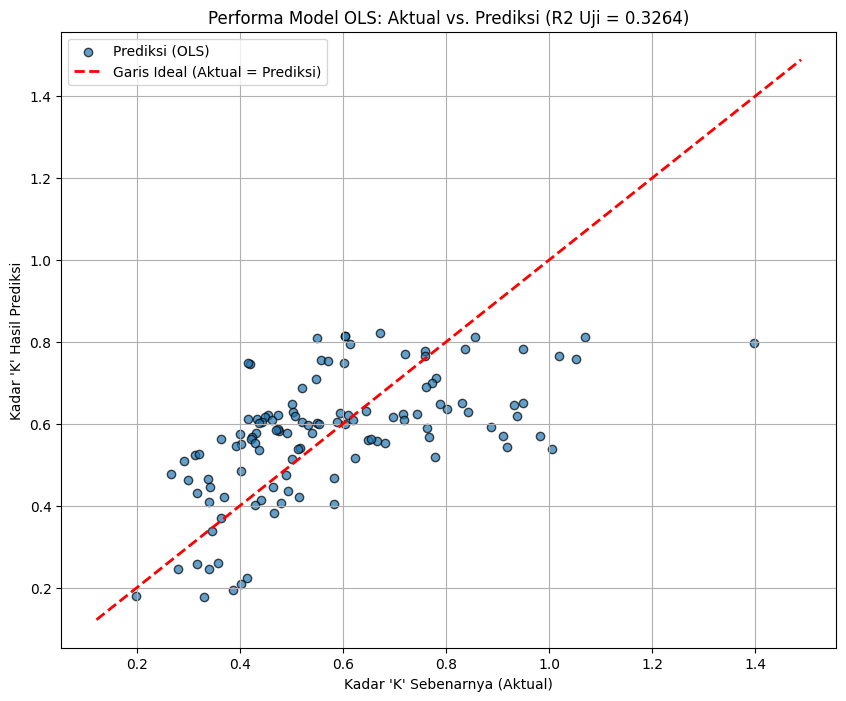

In [14]:
# 9. VISUALISASI HASIL (Sama seperti sebelumnya)
plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_pred_ols, alpha=0.7, edgecolors='k', label='Prediksi (OLS)')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Garis Ideal (Aktual = Prediksi)')
plt.xlabel("Kadar 'K' Sebenarnya (Aktual)")
plt.ylabel("Kadar 'K' Hasil Prediksi")
plt.title(f"Performa Model OLS: Aktual vs. Prediksi (R2 Uji = {r2_test:.4f})")
plt.legend()
plt.grid(True)
plt.savefig('prediksi_K_vs_OLS.png')

print("\nGrafik visualisasi telah disimpan sebagai 'prediksi_K_vs_OLS.png'")